# **Neural Network**

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**


In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

from sympy.printing.tensorflow import tensorflow

%matplotlib inline

In [2]:
# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
df = pd.read_csv(url)


target = 'cnt'
features = [
    'temp','atemp','hum','windspeed','weathersit',
    'hr','weekday','workingday','holiday','season','yr'
]

X = df[features].copy()
y = df[target].astype(float)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**(Optional) quick baseline (Linear Regression)**

In [3]:
# A super-fast baseline, just for context

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({"LR_RMSE": rmse_lr, "LR_MAE": mae_lr, "LR_R2": r2_lr})

{'LR_RMSE': 19379.312944744703, 'LR_MAE': 104.79577059911452, 'LR_R2': 0.3879974354720257}


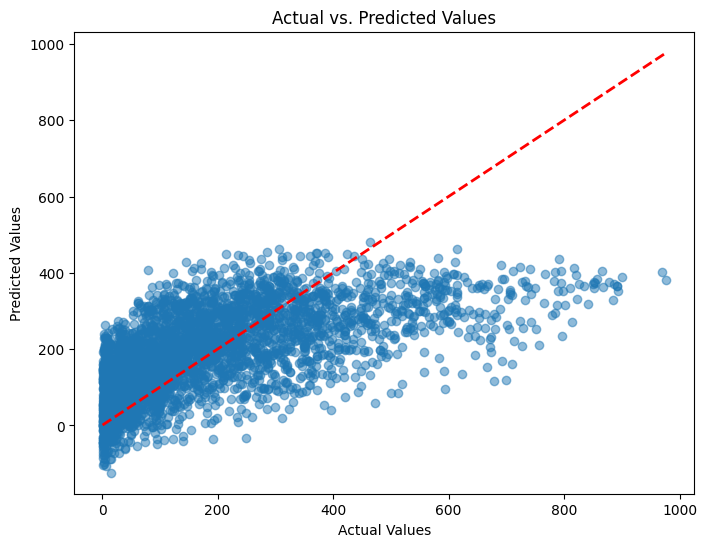

In [4]:
# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

# **Assignment task: Find the best neural network model for the count of rental bikes prediction (assignment submission)**
Tuning the neural network models (e.g., dropout, sizing of the network), and finding the best neural network model. Suggestions:
- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).

## Tune hyperparameters

In [5]:
def create_model(hidden_layers, learning_rate):

    model = keras.Sequential()

    model.add(
        keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    )

    for units in hidden_layers:
        model.add(
            keras.layers.Dense(
                units,
                activation="relu"
            )
        )

    model.add(keras.layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mae",
        metrics=["mae"]
    )

    return model

In [6]:
def train_model(hidden_layers, learning_rate, batch_size, early_stopping_patience, reduce_lr_patience, reduce_lr_factor):

    tf.keras.backend.clear_session()

    model = create_model(
        hidden_layers=hidden_layers,
        learning_rate=learning_rate
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=early_stopping_patience,
        restore_best_weights=True
    )

    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=reduce_lr_factor,
        patience=reduce_lr_patience,
        min_lr=1e-6
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.10,
        epochs=100,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            reduce_lr
        ],
        verbose=0
    )

    best_val_mae = min(history.history["val_mae"])

    return model, history, best_val_mae

In [7]:
training_configs = [
    # Baseline
    {"batch_size": 32, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.5},

    # Larger batch
    {"batch_size": 64, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.5},

    # Smaller batch
    {"batch_size": 16, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.5},

    # More patience
    {"batch_size": 32, "early_stopping_patience": 20, "reduce_lr_patience": 8, "reduce_lr_factor": 0.5},

    # Less patience
    {"batch_size": 32, "early_stopping_patience": 5, "reduce_lr_patience": 3, "reduce_lr_factor": 0.5},

    # Aggressive LR reduction
    {"batch_size": 32, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.1},

    # Moderate LR reduction
    {"batch_size": 32, "early_stopping_patience": 10, "reduce_lr_patience": 5, "reduce_lr_factor": 0.2},

    # Slow LR reduction
    {"batch_size": 32, "early_stopping_patience": 20, "reduce_lr_patience": 10, "reduce_lr_factor": 0.5}
]

In [8]:
results = []

for i, config in enumerate(training_configs):

    print(f"Model {i+1}/{len(training_configs)}")
    print(config)

    model, history, val_mae = train_model(
        hidden_layers=(32, 64),
        learning_rate=0.001,
        **config
    )

    results.append({
        **config,
        "val_mae": val_mae
    })

Model 1/8
{'batch_size': 32, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.5}
Model 2/8
{'batch_size': 64, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.5}
Model 3/8
{'batch_size': 16, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.5}
Model 4/8
{'batch_size': 32, 'early_stopping_patience': 20, 'reduce_lr_patience': 8, 'reduce_lr_factor': 0.5}
Model 5/8
{'batch_size': 32, 'early_stopping_patience': 5, 'reduce_lr_patience': 3, 'reduce_lr_factor': 0.5}
Model 6/8
{'batch_size': 32, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.1}
Model 7/8
{'batch_size': 32, 'early_stopping_patience': 10, 'reduce_lr_patience': 5, 'reduce_lr_factor': 0.2}
Model 8/8
{'batch_size': 32, 'early_stopping_patience': 20, 'reduce_lr_patience': 10, 'reduce_lr_factor': 0.5}


In [9]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "val_mae"
).reset_index(drop=True)

best_training = results_df.iloc[0]

print("Best training configuration:")
print(best_training)

Best training configuration:
batch_size                 16.00000
early_stopping_patience    10.00000
reduce_lr_patience          5.00000
reduce_lr_factor            0.50000
val_mae                    33.12569
Name: 0, dtype: float64


In [10]:
architectures = [(32, 64), (64, 128), (32, 64, 32), (64, 128, 64)]

learning_rates = [0.001, 0.002]

In [11]:
architecture_results = []

for architecture in architectures:

    for lr in learning_rates:

        print(
            f"Architecture: {architecture}, "
            f"Learning rate: {lr}"
        )

        model, history, val_mae = train_model(
            hidden_layers=architecture,
            learning_rate=lr,
            batch_size=int(best_training["batch_size"]),
            early_stopping_patience=int(
                best_training["early_stopping_patience"]
            ),
            reduce_lr_patience=int(
                best_training["reduce_lr_patience"]
            ),
            reduce_lr_factor=float(
                best_training["reduce_lr_factor"]
            )
        )

        architecture_results.append({
            "architecture": architecture,
            "learning_rate": lr,
            "val_mae": val_mae
        })

Architecture: (32, 64), Learning rate: 0.001
Architecture: (32, 64), Learning rate: 0.002
Architecture: (64, 128), Learning rate: 0.001
Architecture: (64, 128), Learning rate: 0.002
Architecture: (32, 64, 32), Learning rate: 0.001
Architecture: (32, 64, 32), Learning rate: 0.002
Architecture: (64, 128, 64), Learning rate: 0.001
Architecture: (64, 128, 64), Learning rate: 0.002


In [12]:
architecture_results_df = pd.DataFrame(
    architecture_results
)

architecture_results_df = (
    architecture_results_df
    .sort_values("val_mae")
    .reset_index(drop=True)
)

best_architecture = architecture_results_df.iloc[0]

print("Best architecture:")
print(best_architecture)

Best architecture:
architecture     (64, 128, 64)
learning_rate            0.002
val_mae              24.533142
Name: 0, dtype: object


## Create a new model
Creating a Sequential model according to the best training configuration and architecture found:

Best training configuration:

* batch_size: 16
* early_stopping_patience: 10
* reduce_lr_patience: 5
* reduce_lr_factor: 0.5


Best architecture:

* architecture: (64, 128, 64)
* learning_rate: 0.002


In [13]:
arch = best_architecture["architecture"]
lr = best_architecture["learning_rate"]

final_model = Sequential()

final_model.add(Dense(arch[0], activation = 'relu', input_dim = 11))

final_model.add(Dense(arch[1], activation = 'relu', input_dim = 11))

final_model.add(Dense(arch[2], activation = 'relu', input_dim = 11))

final_model.compile(optimizer = keras.optimizers.Adam(learning_rate=lr), loss = 'mae', metrics = ['mae'])

final_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,344 (67.75 KB)

 Trainable params: 17,344 (67.75 KB)

 Non-trainable params: 0 (0.00 B)

[]

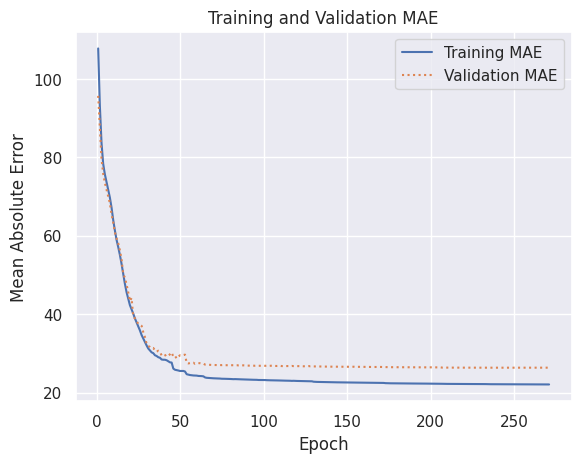

In [14]:
bs = best_training["batch_size"]
esp = best_training["early_stopping_patience"]
rlp = best_training["reduce_lr_patience"]
rlf = best_training["reduce_lr_factor"]

early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=esp, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=rlf, patience=rlp, min_lr=1e-6)

hist = final_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=500, batch_size=int(bs), callbacks=[early_stopping, reduce_lr], verbose=0)

sns.set()

err = hist.history['mae']
val_err = hist.history['val_mae']

epochs = range(1, len(err) + 1)

plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()

In [15]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Neural Network VS Baseline Model (Linear Regression)")
print("----------------------------------------------------------")
print(f"MAE:  {mae:.4f}\t\t|  MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse:.4f}\t\t|  RMSE: {rmse_lr:.4f}")
print(f"R2:   {r2:.4f}\t\t|  R2: {r2_lr:.4f}")


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Final Neural Network VS Baseline Model (Linear Regression)
----------------------------------------------------------
MAE:  24.3818		|  MAE: 104.7958
RMSE: 40.8905		|  RMSE: 19379.3129
R2:   0.9472		|  R2: 0.3880


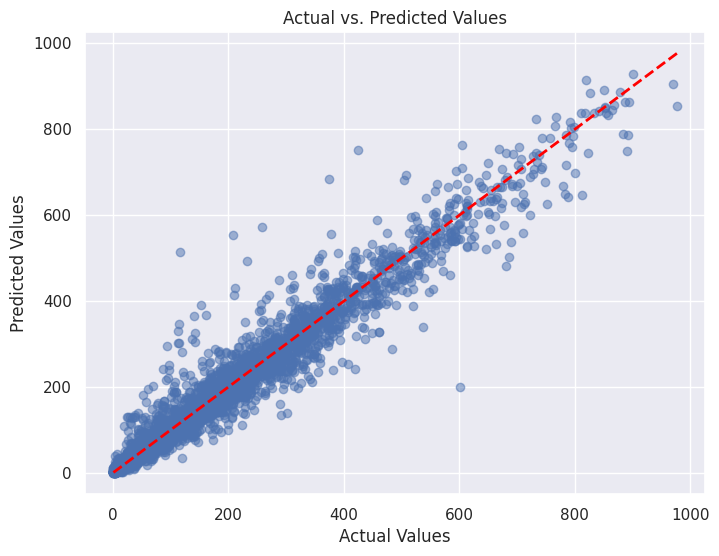

In [16]:
# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()